In [1]:
# ============================================================
# Notebook 16
# Explainable AI (SHAP)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
# ============================================================
# Load Hybrid AI Dataset
# ============================================================

# Load dataset
hybrid_df = pd.read_csv("../data/final/hybrid_ai_risk_assessment.csv")

# Display basic information
print("Dataset Shape:", hybrid_df.shape)

# Display first five rows
hybrid_df.head()

Dataset Shape: (7516, 94)


,icao24,callsign,origin_country,time_position,last_constant,longitude,latitude,baro_altitude,on_ground,velocity,...,GMM_Anomaly_Score,GMM_Anomaly_Label,ELM_Reconstruction_Error,ELM_Anomaly_Score,ELM_Anomaly_Label,Behavioural_Intelligence_Score,Operational_Intelligence_Score,Hybrid_Raw_Risk,Hybrid_Flight_Risk_Score,Hybrid_Risk_Category
0,80162D,AXB848,India,1.767745e+09,1767745048,52.7391,25.4425,9608.82,False,257.34,...,24.597643,Normal,0.026762,0.026762,Normal,0.249354,0.386967,0.290638,34.257313,Medium
1,AE1FA0,72209,United States,1.767745e+09,1767745047,-84.9380,38.1463,571.50,False,73.38,...,13.268496,Normal,0.001748,0.001748,Normal,0.143108,0.386967,0.216265,15.932230,Low
2,AC96B8,AAL1175,United States,1.767745e+09,1767745048,-102.0238,34.0962,10363.20,False,196.90,...,9.193104,Normal,0.001536,0.001536,Normal,0.273887,0.386967,0.307811,38.488734,Medium
3,C81BD3,ZKAMK,New Zealand,1.767745e+09,1767744917,174.5408,-35.8060,624.84,False,56.90,...,22.127363,Normal,0.008986,0.008986,Normal,0.201633,0.386967,0.257233,26.026544,Medium
4,AA56DB,UAL2447,United States,1.767745e+09,1767745048,-102.7402,37.4696,10972.80,False,200.08,...,9.478866,Normal,0.001448,0.001448,Normal,0.275717,0.386967,0.309092,38.804378,Medium


In [3]:
# ============================================================
# Dataset Information
# ============================================================

hybrid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 94 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   icao24                           7516 non-null   object 
 1   callsign                         7500 non-null   object 
 2   origin_country                   7516 non-null   object 
 3   time_position                    7516 non-null   float64
 4   last_constant                    7516 non-null   int64  
 5   longitude                        7516 non-null   float64
 6   latitude                         7516 non-null   float64
 7   baro_altitude                    7516 non-null   float64
 8   on_ground                        7516 non-null   bool   
 9   velocity                         7516 non-null   float64
 10  true_track                       7516 non-null   float64
 11  vertical_rate                    7516 non-null   float64
 12  geo_altitude        

In [4]:
# ============================================================
# Missing Values
# ============================================================

missing = hybrid_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

squawk                    4286
YEAR MFR                  3255
Aircraft_Age              3255
AIR WORTH DATE            3201
ENG MFR MDL               3201
CERTIFICATION             3189
EXPIRATION DATE           3055
CERT ISSUE DATE           3055
SERIAL NUMBER             3049
N-NUMBER                  3049
MFR MDL CODE              3049
ENGINE_TYPE_CODE          3049
TYPE AIRCRAFT             3049
LAST ACTION DATE          3049
TYPE ENGINE               3049
MODE S CODE               3049
STATUS CODE               3049
UNIQUE ID                 3049
MODE S CODE HEX           3049
MANUFACTURER              3049
AIRCRAFT_MODEL            3049
AIRCRAFT_TYPE_CODE        3049
TYPE REGISTRANT           3049
CERTIFICATE_HOLDER        3049
AIRCRAFT_CATEGORY         3049
NUMBER_OF_ENGINES         3049
BUILD_CERTIFICATE         3049
WEIGHT_CLASS              3049
CRUISE_SPEED              3049
TYPE_CERTIFICATE          3049
SEAT_CAPACITY             3049
Weight_Category           3049
Aircraft

In [5]:
# ============================================================
# Display All Columns
# ============================================================

for col in hybrid_df.columns:
    print(col)

icao24
callsign
origin_country
time_position
last_constant
longitude
latitude
baro_altitude
on_ground
velocity
true_track
vertical_rate
geo_altitude
squawk
spi
position_source
flight_phase
speed_category
altitude_band
vertical_movement
heading_direction
operational_risk
N-NUMBER
SERIAL NUMBER
MFR MDL CODE
ENG MFR MDL
YEAR MFR
TYPE REGISTRANT
LAST ACTION DATE
CERT ISSUE DATE
CERTIFICATION
TYPE AIRCRAFT
TYPE ENGINE
STATUS CODE
MODE S CODE
AIR WORTH DATE
EXPIRATION DATE
UNIQUE ID
MODE S CODE HEX
MANUFACTURER
AIRCRAFT_MODEL
AIRCRAFT_TYPE_CODE
ENGINE_TYPE_CODE
AIRCRAFT_CATEGORY
BUILD_CERTIFICATE
NUMBER_OF_ENGINES
SEAT_CAPACITY
WEIGHT_CLASS
CRUISE_SPEED
TYPE_CERTIFICATE
CERTIFICATE_HOLDER
Aircraft_Age
Aircraft_Age_Category
Engine_Configuration
Seat_Capacity_Category
Weight_Category
Cruise_Speed_Category
Manufacturer_Group
Aircraft_Size_Category
distance_to_airport_km
nearest_ident
nearest_name
nearest_municipality
nearest_iso_country
nearest_airport_size
nearest_airport_category
nearest_airp

In [6]:
# ============================================================
# Select Features for Explainable AI
# ============================================================

features = [
    "velocity",
    "baro_altitude",
    "geo_altitude",
    "vertical_rate",
    "true_track",
    "distance_to_airport_km",
    "Operational_Complexity_Index",
    "Flight_Operational_Score",
    "GMM_Anomaly_Score",
    "ELM_Anomaly_Score"
]

target = "Hybrid_Flight_Risk_Score"

# Create feature matrix
X = hybrid_df[features]

# Target
y = hybrid_df[target]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (7516, 10)
Target Shape: (7516,)


In [7]:
# ============================================================
# Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 6012
Testing Samples: 1504


In [8]:
# ============================================================
# Train Explainable Model
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [9]:
# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error

predictions = rf_model.predict(X_test)

print("R² Score :", round(r2_score(y_test, predictions), 4))
print("MAE      :", round(mean_absolute_error(y_test, predictions), 4))

R² Score : 0.9879
MAE      : 0.526


In [10]:
# ============================================================
# Create SHAP Explainer
# ============================================================

import shap

# Create Tree Explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


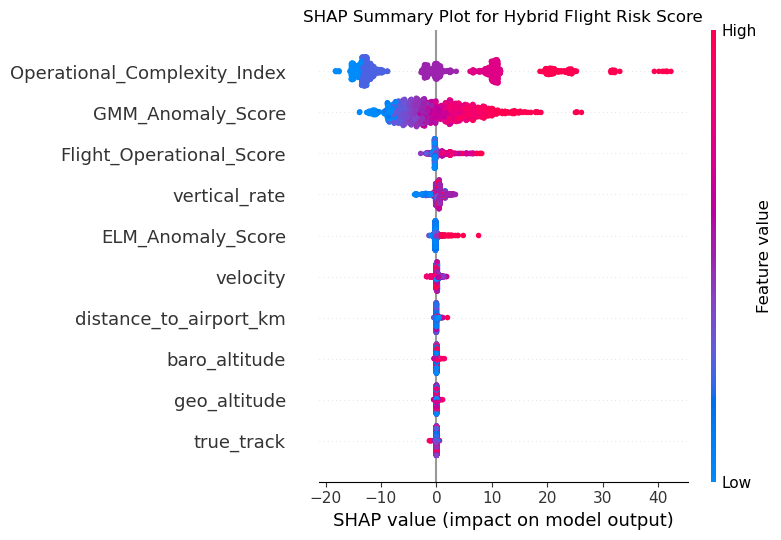

In [15]:
# ============================================================
# SHAP Summary Plot
# ============================================================

import os
import matplotlib.pyplot as plt

os.makedirs("../dashboard/assets", exist_ok=True)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot for Hybrid Flight Risk Score")
plt.tight_layout()

plt.savefig(
    "../dashboard/assets/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

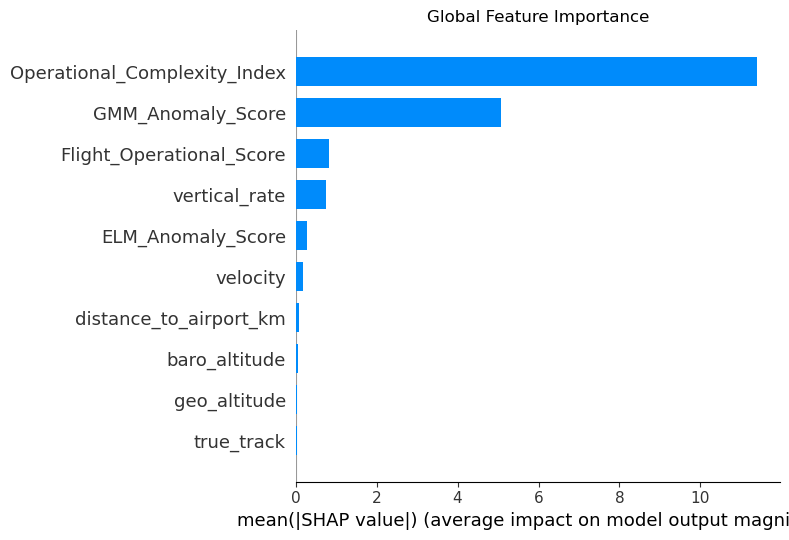

In [12]:
# ============================================================
# SHAP Feature Importance
# ============================================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance")

plt.tight_layout()

plt.show()

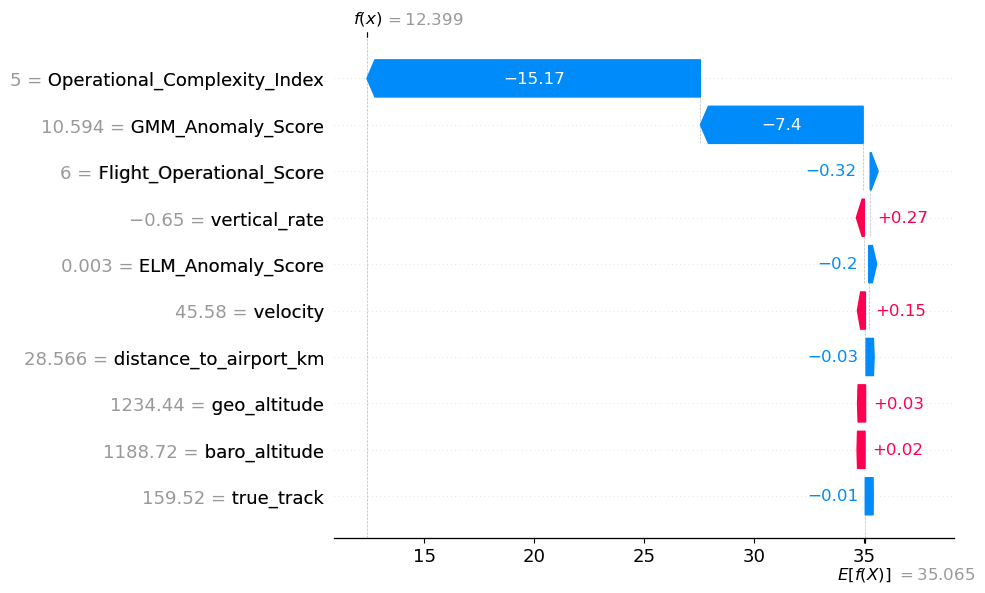

In [16]:
# ============================================================
# SHAP Waterfall Plot
# ============================================================

import os
import matplotlib.pyplot as plt

os.makedirs("../dashboard/assets", exist_ok=True)

plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig(
    "../dashboard/assets/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

<Figure size 1000x600 with 0 Axes>

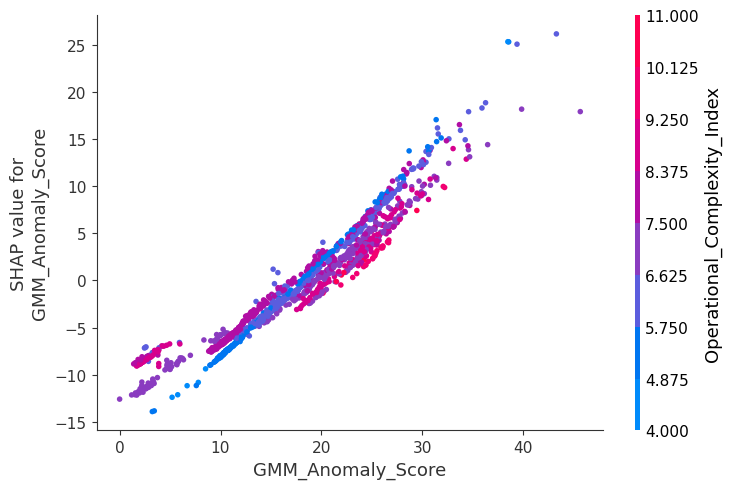

In [17]:
# ============================================================
# SHAP Dependence Plot
# ============================================================

import os
import matplotlib.pyplot as plt

os.makedirs("../dashboard/assets", exist_ok=True)

plt.figure(figsize=(10, 6))

shap.dependence_plot(
    "GMM_Anomaly_Score",
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../dashboard/assets/shap_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()